# Comparing Basic Fairness Metrics

**TrustAI Internship — First Task** · Osman Eren Doğan

A simple binary classifier is trained on synthetic credit data, then audited with three
standard fairness metrics: **demographic parity**, **equal opportunity** and
**disparate impact**. Each metric is explained in plain language, and we ask whether the
model looks fair according to each one.

This notebook **presents** results. Produce them first:

```bash
python ../src/data_prep.py
python ../src/train_model.py
python ../src/fairness_metrics.py
```


## 1. The data and the groups

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

RESULTS = Path("results")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

groups = pd.read_csv(RESULTS / "group_summary.csv")
groups

,attribute,group,role,n,share,true_delinquency_rate
0,education,below university,protected,72606,0.7261,0.3284
1,education,university+,reference,27394,0.2739,0.0869
2,age,young (<30),protected,18169,0.1817,0.3988
3,age,30+,reference,81831,0.8183,0.2320
4,home_ownership,non-homeowner,protected,32704,0.3270,0.5241
5,home_ownership,homeowner,reference,67296,0.6730,0.1350


100,000 synthetic credit applicants. The target is `delinquency_FL` — 1 means the applicant
fell behind on payments.

Three sensitive attributes are audited. Note the **true delinquency rates differ a lot between
groups**: 32.8 % of below-university applicants default versus 8.7 % of university graduates.
That matters for reading the results — a model that tracks risk accurately *will* approve these
groups at different rates, and demographic parity will flag that even when nothing is wrong with
the model.

## 2. The model

In [2]:
performance = json.loads((RESULTS / "model_performance.json").read_text())
performance

{'model': "LogisticRegression(class_weight='balanced')",
 'n_features': 11,
 'n_train': 80000,
 'n_test': 20000,
 'threshold': 0.5,
 'roc_auc': 0.9136,
 'overall_approval_rate': 0.6618,
 'overall_repayment_rate': 0.7378}

Logistic regression with standard scaling — deliberately simple, since the task is to compare
fairness metrics rather than to maximise accuracy. `class_weight="balanced"` compensates for only
26 % of applicants defaulting.

**Framing.** In lending the favourable outcome is being **approved**. So every metric below is
computed on the approval rate, not on the raw model output.

## 3. The three metrics, in plain language

**Demographic parity** — *"Does the model approve the same share of people in each group?"*
It compares raw approval rates and completely ignores whether people actually repay.

$$P(	ext{approved} \mid 	ext{protected}) - P(	ext{approved} \mid 	ext{reference})$$

Ideal value 0. A common rule of thumb is that a gap up to 0.10 is acceptable.

**Equal opportunity** — *"Among people who genuinely repay, does each group get approved
equally often?"* It looks only at applicants who deserve approval, so it is the merit-aware
view — and usually the harder gap to justify.

$$P(	ext{approved} \mid 	ext{protected}, 	ext{repays}) - P(	ext{approved} \mid 	ext{reference}, 	ext{repays})$$

Ideal value 0, same 0.10 tolerance.

**Disparate impact** — *the legal test.* The protected group's approval rate divided by the
reference group's. The **four-fifths rule** used by regulators treats anything below **0.80** as
evidence of adverse impact.

$$rac{P(	ext{approved} \mid 	ext{protected})}{P(	ext{approved} \mid 	ext{reference})}$$

Ideal value 1.0.

## 4. Results

In [3]:
metrics = pd.read_csv(RESULTS / "fairness_metrics.csv")
metrics[["attribute", "protected_group", "reference_group",
         "approval_rate_protected", "approval_rate_reference"]]

,attribute,protected_group,reference_group,approval_rate_protected,approval_rate_reference
0,education,below university,university+,0.6053,0.8137
1,age,young (<30),30+,0.4545,0.7078
2,home_ownership,non-homeowner,homeowner,0.2445,0.8647


In [4]:
metrics[["attribute",
         "demographic_parity_difference", "demographic_parity_verdict",
         "equal_opportunity_difference", "equal_opportunity_verdict",
         "disparate_impact_ratio", "disparate_impact_verdict"]]

,attribute,demographic_parity_difference,demographic_parity_verdict,equal_opportunity_difference,equal_opportunity_verdict,disparate_impact_ratio,disparate_impact_verdict
0,education,-0.2083,UNFAIR,-0.0283,FAIR,0.7440,UNFAIR
1,age,-0.2532,UNFAIR,-0.1647,UNFAIR,0.6422,UNFAIR
2,home_ownership,-0.6201,UNFAIR,-0.4684,UNFAIR,0.2828,UNFAIR


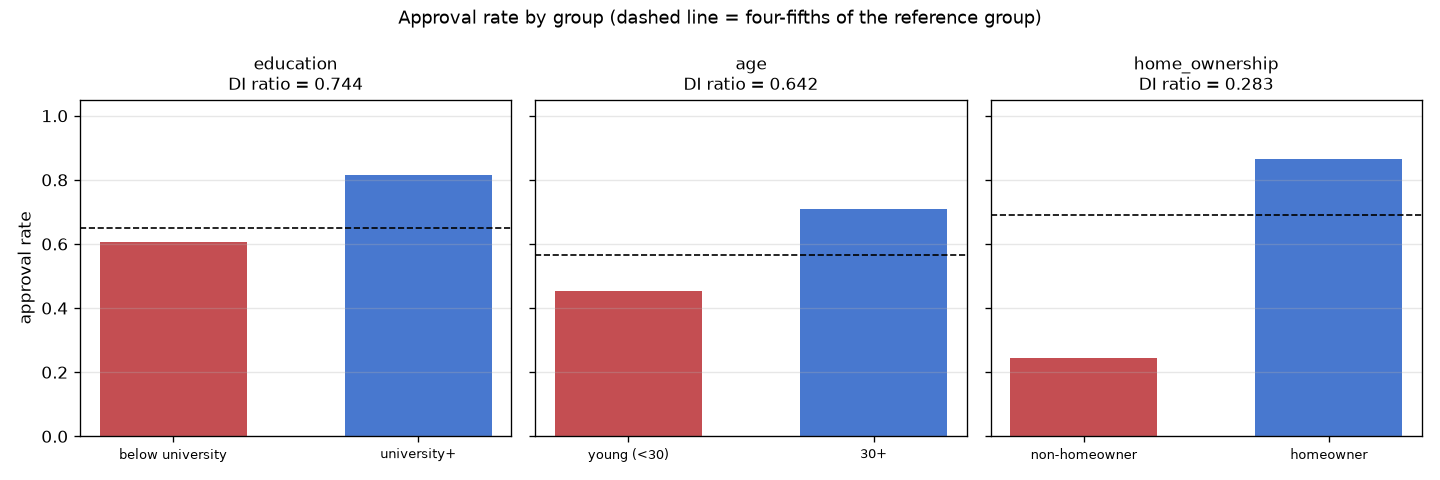

In [5]:
display(Image(filename=str(RESULTS / "fig_approval_rates.png")))

## 5. Is the model fair?

**It depends on which metric you ask — and that is the main lesson here.**

**Education (below university vs university+).** The three metrics disagree.
Demographic parity fails (−0.208): below-university applicants are approved 60.5 % of the time
versus 81.4 %. Disparate impact fails too (0.744, under the 0.80 legal line). But **equal
opportunity passes** (−0.028): among applicants who *genuinely repay*, both groups are approved
at almost exactly the same rate. So the model is not mistreating creditworthy people because of
their education — the approval gap comes from the genuine difference in default rates (32.8 %
vs 8.7 %). Whether that is acceptable is a policy question, not a modelling one.

**Age (young vs 30+).** All three fail. Demographic parity −0.253 and disparate impact 0.642 are
partly explained by base rates (young applicants default 39.9 % vs 23.2 %). But equal opportunity
also fails at −0.165, and that one is not explained away: young applicants who **do** repay are
approved about 16 points less often than older ones who repay. This is the harder problem.

**Home ownership (non-owner vs owner).** All three fail, by the widest margins: a 62-point
approval gap, a disparate impact ratio of 0.283 — barely a third of the legal threshold — and a
47-point equal-opportunity gap. Creditworthy non-homeowners are rejected far more often than
creditworthy homeowners.

### Summary

| Attribute | Demographic parity | Equal opportunity | Disparate impact |
|---|---|---|---|
| Education | ❌ UNFAIR | ✅ FAIR | ❌ UNFAIR |
| Age | ❌ UNFAIR | ❌ UNFAIR | ❌ UNFAIR |
| Home ownership | ❌ UNFAIR | ❌ UNFAIR | ❌ UNFAIR |

Overall the model **would not pass a fairness review**. It fails the four-fifths rule on all
three attributes. Education is the interesting case: it looks unfair on two metrics and fair on
the third, which shows why a single number is never enough — you have to say *which* definition
of fairness you are using.

### Why the metrics disagree

Demographic parity asks only about outcomes. Equal opportunity conditions on who actually repays.
When two groups genuinely default at different rates, these two definitions **cannot both be
satisfied** — this is a known impossibility result (Kleinberg et al.; Chouldechova). Education
shows it directly: conditioning on repayment removes almost the entire gap.

### Limitations

1. The data is **synthetic** — the numbers describe this model and this dataset, not real people.
2. All metrics use a single decision threshold (0.5); a different threshold moves them.
3. Group definitions (age 30 cut-off, education split) are analytic choices.
4. No mitigation is attempted here; the task is to measure and compare.
